# EasySpin Cross-Validation & Spectral Accuracy

Validates the accuracy of the MarS library by directly comparing simulated EPR spectra against reference calculations from EasySpin. It tests a wide range of spin systems (single electrons, coupled chains, heterospin complexes, and polarized radiation cases) to ensure spectral fidelity across different Hamiltonian parameters and magnetic field/frequency domains.

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
import typing as tp
import math
from importlib import reload

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Union, Tuple, List
from mars import spin_model, spectra_manager, mesher, constants
import mars

from sample_creators_local import (
                             create_5_electrons_sample, create_2_electrons_2_nuclei_sample,
                             create_1_high_spin_electron_1_nuclei_sample, create_2_middle_spin_sample,
                             create_3_middle_spin_sample, create_heterospin_sample,
                             create_tripletfission_sample, create_heterospin_sample_freq_domain
                            )

from saving_benchmarks import save_benchmark_results, load_benchmark_results

from bencmarking import benchmark_several_configurations, compare_benchmarks, plot_benchmark_comparison, time_spectrum_calculation_full_pipeline, time_spectrum_calculation_full_pipeline_freqdep

In [48]:
import matplotlib.pyplot as plt
dtype = torch.float64
device = torch.device("cpu")

mesh = mars.mesher.DelaunayMesh(initial_grid_frequency=25, interpolation_grid_frequency=20, interpolator="barycentric", dtype=dtype, interpolate=False)

# 1. Speed Comparison

### Sample 1

In [46]:
sample_Mn = create_1_high_spin_electron_1_nuclei_sample(mesh=mesh, device=device, dtype=dtype)

freq = 35.0 * 1e9,
field_range = (1.15, 1.325)
n_points = 1000
temperature = 300.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_Mn,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_Mn, fields=fields)

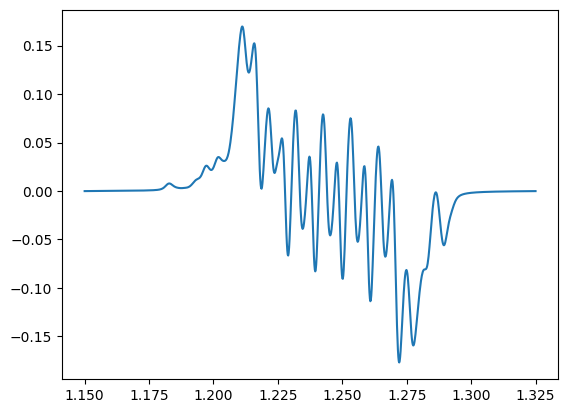

In [42]:
plt.plot(fields, out)

In [43]:
mars.save("easyspin/out_1.mat", sample=sample_Mn, spectra_creator=creator, field=fields, format_type="easyspin")
data_frame = pd.DataFrame({"field": fields, "spec": out})

data_frame.to_csv(f"easyspin/spectrum_1.csv", header=False, index=False)

In [ ]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

time_spectrum_calculation_full_pipeline(
    sample_creation_func=create_1_high_spin_electron_1_nuclei_sample,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    freq=freq, field_range=field_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

### Sample 2

In [37]:
sample_hetero_spins = create_heterospin_sample(mesh=mesh, device=device, dtype=dtype)

freq = 35.0 * 1e9,
field_range = (1.21, 1.29)
n_points = 1000
temperature = 300.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_hetero_spins,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)
    
out = creator(sample=sample_hetero_spins, fields=fields)

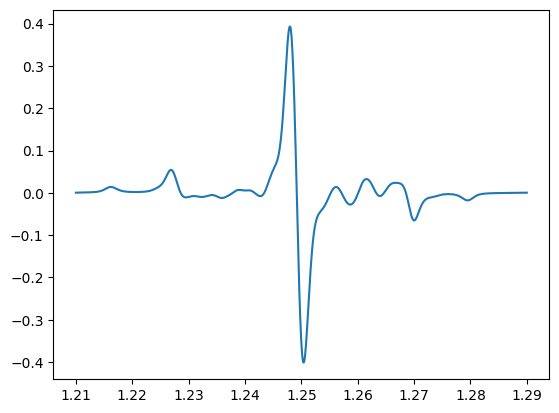

In [38]:
plt.plot(fields, out)

In [39]:
mars.save("easyspin/out_2.mat", sample=sample_hetero_spins, spectra_creator=creator, field=fields, format_type="easyspin")
data_frame = pd.DataFrame({"field": fields, "spec": out})

data_frame.to_csv(f"easyspin/spectrum_2.csv", header=False, index=False)

In [31]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

time_spectrum_calculation_full_pipeline(
    sample_creation_func=create_heterospin_sample,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    freq=freq, field_range=field_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(896.2008600001354,
 29.08630041519416,
 [943.4822000002896,
  882.5570999997581,
  914.5526000002064,
  877.95720000031,
  862.4552000001131])

### Sample 3: SPIN POLARIZED

In [32]:
sample_2_triplets = create_tripletfission_sample(mesh=mesh, device=device, dtype=dtype)

freq = 9.8 * 1e9,
field_range = (0.33, 0.37)
n_points = 1000
temperature = 300.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

init_populations=[0.0] * 9
init_populations[-3] = 1.0
context = mars.population.Context(sample=sample_2_triplets, init_populations=init_populations, dtype=dtype, device=device)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_2_triplets,
    context=context,
    temperature=temperature,
    computational_details=computational_details,
    harmonic=0,
    device=device,
    dtype=dtype
)
    
out = creator(sample=sample_2_triplets, fields=fields)

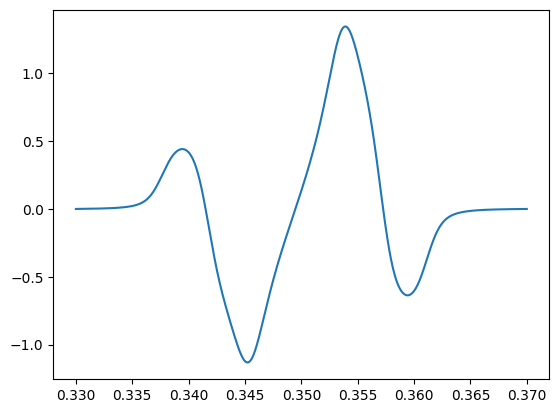

In [33]:
plt.plot(fields, out)

In [34]:
mars.save("easyspin/out_3.mat", sample=sample_2_triplets, spectra_creator=creator, field=fields, format_type="easyspin")
data_frame = pd.DataFrame({"field": fields, "spec": out})

data_frame.to_csv(f"easyspin/spectrum_3.csv", header=False, index=False)

In [35]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

time_spectrum_calculation_full_pipeline(
    sample_creation_func=create_tripletfission_sample,
    context=context,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    freq=freq, field_range=field_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(78.73909999998432,
 4.1903072369115755,
 [77.00700000077632,
  84.44849999978032,
  82.9954999999245,
  74.92399999955524,
  74.32049999988521])

### Sample 4: Polarized Radiation

In [24]:
sample_hetero = create_heterospin_sample_freq_domain(mesh=mesh, device=device, dtype=dtype)

n_points = 1000
temperature = 300.0

freq_range = (0.0, constants.unit_converter(25.0, "cm-1_to_Hz"))
freq = torch.linspace(
            freq_range[0],
            freq_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

field = torch.tensor(10.0, device=device, dtype=dtype)

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-3, res_field_r_tol=1e-4)


intensity_calculator = spectra_manager.WaveIntensityCalculator(
    spin_system_dim=sample_hetero.spin_system_dim,  # spin_system_dim from a sample
    disordered=sample_hetero.mesh.disordered,  # True for powder samples
    polarization='+1',                  # Right-handed (clockwise) circular polarization
    theta=0.0,                  # Propagation perpendicular to static magnetic field
    device=device,
    dtype=dtype,
)

creator = spectra_manager.StationaryFreqSpectra(
    intensity_calculator=intensity_calculator,
    field=field,
    sample=sample_hetero,
    temperature=temperature,
    computational_details=computational_details,
    harmonic=0,
    device=device,
    dtype=dtype
)
    
out = creator(sample=sample_hetero, freq=freq)

D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\spectra_manager\spectra_manager.py:1606: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("resonance_parameter", torch.tensor(resonance_parameter, device=device, dtype=dtype))


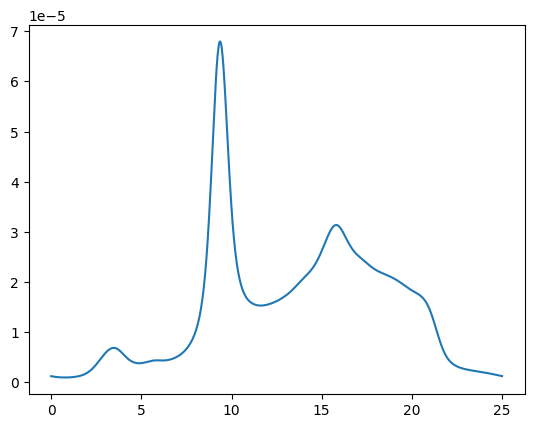

In [25]:
plt.plot(constants.unit_converter(freq, "Hz_to_cm-1"), out)

In [26]:
mars.save("easyspin/out_4.mat", sample=sample_hetero, spectra_creator=creator, field=None, format_type="easyspin")
data_frame = pd.DataFrame({"freq": constants.unit_converter(freq, "Hz_to_cm-1"), "spec": out})

data_frame.to_csv(f"easyspin/spectrum_4.csv", header=False, index=False)

In [27]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

intensity_calculator = spectra_manager.WaveIntensityCalculator(
    spin_system_dim=sample_hetero.spin_system_dim,  # spin_system_dim from a sample
    disordered=sample_hetero.mesh.disordered,  # True for powder samples
    polarization='+1',                  # Right-handed (clockwise) circular polarization
    theta=0.0,                  # Propagation perpendicular to static magnetic field
    device=device,
    dtype=dtype,
)
creator_kwargs = {"intensity_calculator": intensity_calculator}

time_spectrum_calculation_full_pipeline_freqdep(
    sample_creation_func=create_heterospin_sample_freq_domain,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    field=field, freq_range=freq_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(553.5330599999725,
 25.835852049145384,
 [539.594699999725,
  535.3660999999192,
  586.0407000000123,
  582.9655999996248,
  523.698200000581])

# 2. Plot Spectra Together

In [49]:
def read_csv(name: str):
    # Read the CSV file - data is in rows, not columns
    df = pd.read_csv(f".\\easyspin\\{name}.csv", header=None)
    
    # First row is 'fields', second row is 'spectrum'
    # Skip the first column (labels) and get the data
    fields = df.iloc[0, 1:].values.astype(float)
    spectrum = df.iloc[1, 1:].values.astype(float)
    
    # Convert to torch tensors
    fields_tensor = torch.tensor(fields, dtype=dtype, device=device)
    spectrum_tensor = torch.tensor(spectrum, dtype=dtype, device=device)
    
    return fields_tensor, spectrum_tensor

### Sample 1

In [50]:
name = "spec_easy_spin_1"
freq = 35.0 * 1e9,
fields, spectrum_easyspin = read_csv(name)
temperature = 300.0

sample_Mn = create_1_high_spin_electron_1_nuclei_sample(mesh=mesh, device=device, dtype=dtype)
creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_Mn,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_Mn, fields=fields)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


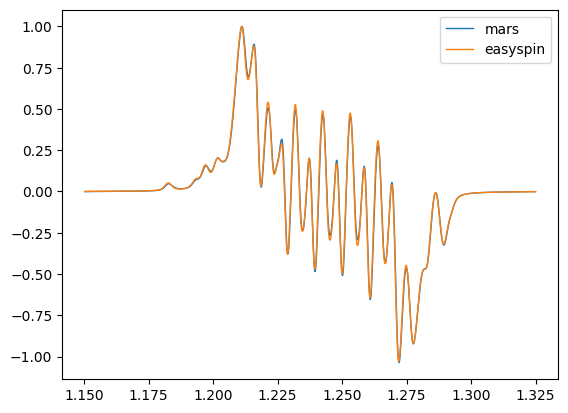

In [51]:
plt.plot(fields, out/ max(out), label="mars", linewidth=1)
plt.plot(fields, spectrum_easyspin / max(spectrum_easyspin), label="easyspin", linewidth=1)
plt.legend()
plt.savefig("example_1.eps")
plt.show()

### Sample 2

In [58]:
name = "spec_easy_spin_2"
freq = 35.0 * 1e9,
fields, spectrum_easyspin = read_csv(name)
temperature = 300.0

sample_hetero_spins = create_heterospin_sample(mesh=mesh, device=device, dtype=dtype)
creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_hetero_spins,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_hetero_spins, fields=fields)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


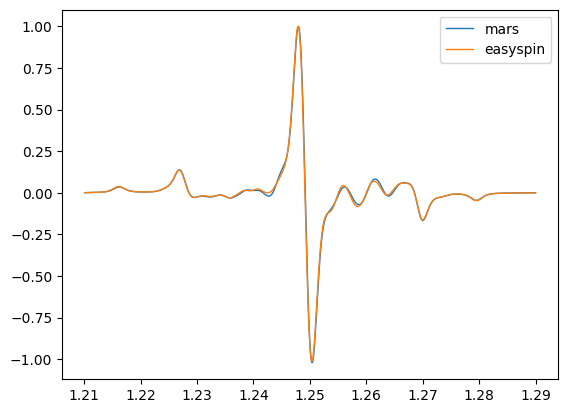

In [59]:
plt.plot(fields, out/ max(out), label="mars", linewidth=1)
plt.plot(fields, spectrum_easyspin / max(spectrum_easyspin), label="easyspin", linewidth=1)
plt.legend()
plt.savefig("example_2.eps")
plt.show()

### Sample 3: Sample Polarized

In [56]:
name = "spec_easy_spin_3"
freq = 9.8 * 1e9,
fields, spectrum_easyspin = read_csv(name)
temperature = 300.0


init_populations=[0.0] * 9
init_populations[-3] = 1.0
context = mars.population.Context(sample=sample_2_triplets, init_populations=init_populations, dtype=dtype, device=device)

sample_2_triplets = create_tripletfission_sample(mesh=mesh, device=device, dtype=dtype)
creator = spectra_manager.StationarySpectra(
    context=context,
    freq=freq,
    sample=sample_2_triplets,
    temperature=temperature,
    harmonic=0,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_2_triplets, fields=fields)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


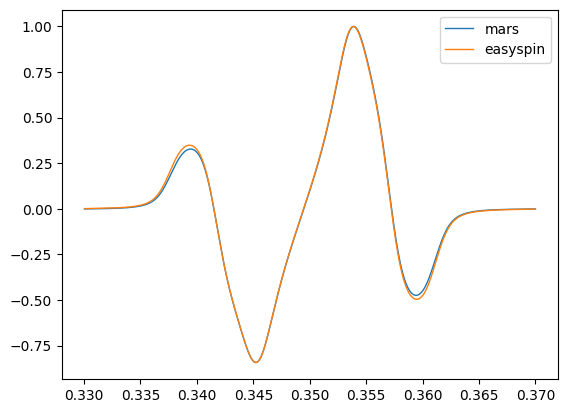

In [57]:
plt.plot(fields, out/ max(out), label="mars", linewidth=1)
plt.plot(fields, spectrum_easyspin / max(spectrum_easyspin), label="easyspin", linewidth=1)
plt.legend()
plt.savefig("example_3.eps")
plt.show()

freq### Sample 4: Polarized Radiation

In [62]:
freq[-1]

tensor(749.4811, dtype=torch.float64)

In [63]:
name = "spec_easy_spin_4"
field = 10.0,
freq, spectrum_easyspin = read_csv(name)
freq = freq * 1e9
temperature = 300.0

sample_hetero = create_heterospin_sample_freq_domain(mesh=mesh, device="cpu", dtype=dtype)

intensity_calculator = spectra_manager.WaveIntensityCalculator(
    spin_system_dim=sample_hetero.spin_system_dim,  # spin_system_dim from a sample
    disordered=sample_hetero.mesh.disordered,  # True for powder samples
    polarization='+1',                  # Right-handed (clockwise) circular polarization
    theta=0.0,                  # Propagation perpendicular to static magnetic field
    device=device,
    dtype=dtype,
)

creator = spectra_manager.StationaryFreqSpectra(
    intensity_calculator=intensity_calculator,
    field=field,
    sample=sample_hetero,
    temperature=temperature,
    computational_details=computational_details,
    harmonic=0,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_hetero, freq=freq)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


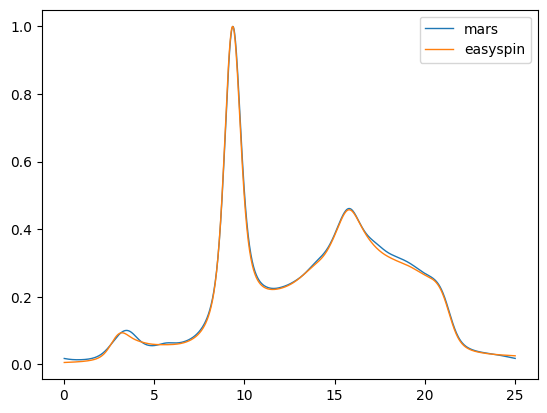

In [64]:
freq_cm = constants.unit_converter(freq, "Hz_to_cm-1")
plt.plot(freq_cm, out/ max(out), label="mars", linewidth=1)
plt.plot(freq_cm, spectrum_easyspin / max(spectrum_easyspin), label="easyspin", linewidth=1)
plt.legend()
plt.savefig("example_4.eps")
plt.show()